# Coverage over time — Cultura vs Cross-Verified
Individuals per 50-year bin, globally and by continent (Cultura V2 vs Laouenan et al. 2022).

## Configuration

In [1]:
import duckdb
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from constants import CONTINENTS, LATIN_AMERICAN_COUNTRIES, MIDDLE_EAST_COUNTRIES

SEED = 42
DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'

ADULT_ONSET_OFFSET = 30
BIN_SIZE = 50
BIN_MIN = -1500
BIN_MAX_START = 1950
bins_50y = np.arange(BIN_MIN, BIN_MAX_START + 1, BIN_SIZE)

COLORS = {'cultura': '#5b8db8', 'cross_verified': '#e0925f'}
FIGSIZE = (14, 5.5)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'DejaVu Sans',
    'font.size': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'legend.frameon': False,
    'axes.formatter.useoffset': False,
})

def format_year_label(year):
    return f'{abs(year)} BCE' if year < 0 else f'{year}'

thousands = ticker.FuncFormatter(lambda y, _: f'{int(y):,}' if y >= 1 else '')

## External data
- **Cross-Verified database** (Laouenan et al. 2022) — `../data/similar_databases/cross_verified.duckdb`, table `individuals`: birth/death years (floruit year) and cleaned citizenships `citizenship_1_b` / `citizenship_2_b` (continent). Attached read-only to the Cultura connection so the joins on Wikidata qid run in SQL.

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql("SET memory_limit='3GB'; SET threads=4;")
con.sql(f"ATTACH '{CROSS_VERIFIED_DB_PATH}' AS cv (READ_ONLY)")

con.sql(f"""
    CREATE TEMP TABLE cv_years AS
    SELECT wikidata_code AS qid, citizenship_1_b, citizenship_2_b,
           CASE
               WHEN birth IS NOT NULL AND COALESCE(death, updated_death_date) IS NOT NULL
                   THEN CAST((birth + COALESCE(death, updated_death_date)) / 2 AS BIGINT)
               WHEN birth IS NOT NULL THEN birth + {ADULT_ONSET_OFFSET}
               WHEN COALESCE(death, updated_death_date) IS NOT NULL
                   THEN COALESCE(death, updated_death_date) - {ADULT_ONSET_OFFSET}
           END AS year
    FROM cv.individuals
""")
print(con.sql('SELECT count(*) AS rows, count(year) AS with_year FROM cv_years').pl())
con.sql('SELECT * FROM cv_years LIMIT 5').pl()

shape: (1, 2)
┌─────────┬───────────┐
│ rows    ┆ with_year │
│ ---     ┆ ---       │
│ i64     ┆ i64       │
╞═════════╪═══════════╡
│ 2291817 ┆ 2141505   │
└─────────┴───────────┘


qid,citizenship_1_b,citizenship_2_b,year
str,str,str,i64
"""Q1000002""","""Germany""",null,1961
"""Q1000005""","""Czech_Republic""",null,1894
"""Q1000006""","""Germany""",null,2001
"""Q1000015""","""Germany""",null,2013
"""Q1000023""","""Germany""",null,1944


## Load Cultura data

### Effective year per individual
midpoint(birth, death) → birth + 30 → death − 30 → Wikidata floruit (P2031) → midpoint of the peak-productivity window (`individual_enriched.peak_productivity`). The 57 fictional individuals (`is_human = false`) are excluded.

In [3]:
con.sql(f"""
    CREATE TEMP TABLE cultura_years AS
    SELECT i.entity.qid AS qid,
           COALESCE(
               CASE WHEN len(i.birth_date) > 0 AND len(i.death_date) > 0
                    THEN CAST((i.birth_date[1].year + i.death_date[1].year) / 2 AS BIGINT) END,
               i.birth_date[1].year + {ADULT_ONSET_OFFSET},
               i.death_date[1].year - {ADULT_ONSET_OFFSET},
               i.floruit_date[1].year,
               CAST((e.peak_productivity.start_year + e.peak_productivity.end_year) / 2 AS BIGINT),
               e.peak_productivity.start_year,
               e.peak_productivity.end_year
           ) AS year
    FROM individual i
    LEFT JOIN individual_enriched e ON e.entity.qid = i.entity.qid
    WHERE i.is_human
""")
cultura_year_stats = con.sql('SELECT count(*) AS individuals, count(year) AS with_year, count(DISTINCT qid) AS distinct_qid FROM cultura_years').pl()
assert cultura_year_stats['individuals'][0] == cultura_year_stats['distinct_qid'][0]
print(f"with at least one date: {cultura_year_stats['with_year'][0]:,} / {cultura_year_stats['individuals'][0]:,}")
con.sql('SELECT * FROM cultura_years WHERE year IS NOT NULL LIMIT 5').pl()

with at least one date: 9,968,868 / 13,002,840


qid,year
str,i64
"""Q115837810""",1900
"""Q115837812""",1912
"""Q115837814""",1908
"""Q115837817""",1906
"""Q115837819""",1909


### Present-day state per individual
Each place (birth, death, country of citizenship) is resolved to its present-day state: the place's own `present_day_state`, else that of its `country`. Polity territories carry no `present_day_states` in V2 (empty lists), so the old polity → modern-country route is replaced by this place route. An individual can map to several states.

In [4]:
con.sql("""
    CREATE TEMP TABLE place_state AS
    SELECT p.entity.qid AS place_qid,
           COALESCE(p.present_day_state.name, c.present_day_state.name) AS state,
           COALESCE(p.present_day_state.continent, c.present_day_state.continent) AS native_continent
    FROM place p
    LEFT JOIN place c ON c.entity.qid = p.country.qid
    WHERE COALESCE(p.present_day_state.name, c.present_day_state.name) IS NOT NULL
""")
con.sql("""
    CREATE TEMP TABLE cultura_state AS
    SELECT DISTINCT x.qid, s.state
    FROM (
        SELECT entity.qid AS qid, place_of_birth.entity.qid AS place_qid FROM individual
        UNION ALL
        SELECT entity.qid, place_of_death.entity.qid FROM individual
        UNION ALL
        SELECT qid, c.entity.qid FROM (SELECT entity.qid AS qid, unnest(country_of_citizenship) AS c FROM individual)
    ) x
    JOIN place_state s USING (place_qid)
""")
print(con.sql('SELECT count(*) AS places_with_state FROM place_state').pl())
print(con.sql('SELECT count(*) AS pairs, count(DISTINCT qid) AS individuals FROM cultura_state').pl())
con.sql('SELECT * FROM cultura_state LIMIT 5').pl()

shape: (1, 1)
┌───────────────────┐
│ places_with_state │
│ ---               │
│ i64               │
╞═══════════════════╡
│ 304876            │
└───────────────────┘
shape: (1, 2)
┌─────────┬─────────────┐
│ pairs   ┆ individuals │
│ ---     ┆ ---         │
│ i64     ┆ i64         │
╞═════════╪═════════════╡
│ 6993129 ┆ 6219380     │
└─────────┴─────────────┘


qid,state
str,str
"""Q108909152""","""United States"""
"""Q108919951""","""Czech Republic"""
"""Q108920134""","""Czech Republic"""
"""Q112274975""","""Germany"""
"""Q112326570""","""Poland"""


## Preprocessing

### State → continent (Latin-America and Middle-East overrides)

In [5]:
def regroup_continent(state, native_continent):
    if state in MIDDLE_EAST_COUNTRIES:
        return 'Middle East'
    if state in LATIN_AMERICAN_COUNTRIES:
        return 'Latin America'
    if native_continent in {'North America', 'South America'}:
        return 'North America'
    if native_continent in {'Europe', 'Asia', 'Africa'}:
        return native_continent
    return None

state_continent_raw = con.sql('SELECT DISTINCT state, native_continent FROM place_state').pl()
state_continent = (
    state_continent_raw
    .with_columns(pl.struct('state', 'native_continent')
                  .map_elements(lambda r: regroup_continent(r['state'], r['native_continent']), return_dtype=pl.Utf8)
                  .alias('continent'))
    .filter(pl.col('continent').is_not_null())
    .unique('state')
    .select('state', 'continent')
)
state_to_continent = dict(state_continent.iter_rows())
con.register('state_continent', state_continent)
print(f'states: {state_continent_raw.height} → mapped to a continent: {state_continent.height}')
state_continent.group_by('continent').len().sort('len', descending=True)

states: 271 → mapped to a continent: 233


continent,len
str,u32
"""Europe""",61
"""Africa""",61
"""Asia""",35
"""Latin America""",34
"""North America""",25
"""Middle East""",17


### Cross-Verified citizenship → continent
Citizenship strings are matched to V2 present-day state names, with a small alias table (historical entities such as Roman Empire or Holy Roman Empire stay unmapped).

In [6]:
CV_CITIZENSHIP_ALIAS = {
    'US': 'United States', 'United_States': 'United States',
    'UK': 'United Kingdom', 'Great_Britain': 'United Kingdom',
    'Netherlands': 'Kingdom of the Netherlands',
    'China': "People's Republic of China", 'Hong_Kong': "People's Republic of China",
    'Czechoslovakia': 'Czech Republic', 'Yugoslavia': 'Serbia', 'Macedonia': 'North Macedonia',
    'East_Timor': 'Timor-Leste', 'Vatican': 'Vatican City', 'Burma': 'Myanmar',
    'Ivory_Coast': 'Ivory Coast', 'Gambia': 'The Gambia', 'Swaziland': 'Eswatini',
    'Dominican_republic': 'Dominican Republic', 'Congo_Republic': 'Republic of the Congo',
}

cv_tokens = con.sql("""
    SELECT DISTINCT c AS citizenship FROM (
        SELECT citizenship_1_b AS c FROM cv_years UNION ALL SELECT citizenship_2_b FROM cv_years
    ) WHERE c IS NOT NULL
""").pl()
cv_citizenship_continent = (
    cv_tokens
    .with_columns(pl.col('citizenship').map_elements(
        lambda c: state_to_continent.get(CV_CITIZENSHIP_ALIAS.get(c, c.replace('_', ' '))), return_dtype=pl.Utf8
    ).alias('continent'))
    .filter(pl.col('continent').is_not_null())
)
con.register('cv_citizenship_continent', cv_citizenship_continent)
print(f'CV citizenship values: {cv_tokens.height} → mapped: {cv_citizenship_continent.height}')
cv_citizenship_continent.head()

CV citizenship values: 245 → mapped: 189


citizenship,continent
str,str
"""Italy""","""Europe"""
"""United_Kingdom""","""Europe"""
"""Norway""","""Europe"""
"""Hungary""","""Europe"""
"""Ireland""","""Europe"""


### Individual ↔ continent ↔ year
Cultura: present-day state route. Cross-Verified: `citizenship_1_b` ∪ `citizenship_2_b`. As in the original analysis, Cultura is augmented with the Cross-Verified continent/year of the individuals present in both databases (so Laouenan 2022 ⊂ Cultura per continent and bin).

In [7]:
con.sql("""
    CREATE TEMP TABLE cv_continent AS
    SELECT DISTINCT y.qid, m.continent, y.year
    FROM cv_years y
    JOIN cv_citizenship_continent m ON m.citizenship IN (y.citizenship_1_b, y.citizenship_2_b)
    WHERE y.year IS NOT NULL
""")
con.sql("""
    CREATE TEMP TABLE cultura_continent AS
    SELECT DISTINCT s.qid, m.continent, y.year
    FROM cultura_state s
    JOIN state_continent m USING (state)
    JOIN cultura_years y USING (qid)
    WHERE y.year IS NOT NULL
""")
n_before = con.sql('SELECT count(*) FROM cultura_continent').fetchone()[0]
con.sql("""
    INSERT INTO cultura_continent
    SELECT cv.qid, cv.continent, cv.year FROM cv_continent cv
    WHERE cv.qid IN (SELECT qid FROM cultura_years)
    EXCEPT SELECT qid, continent, year FROM cultura_continent
""")
n_after = con.sql('SELECT count(*) FROM cultura_continent').fetchone()[0]
print(f'Cultura (qid, continent, year) rows: {n_before:,} → {n_after:,} after CV augmentation')
print(f"CV (qid, continent, year) rows: {con.sql('SELECT count(*) FROM cv_continent').fetchone()[0]:,}")
con.sql('SELECT * FROM cultura_continent USING SAMPLE 5 ROWS (reservoir, 42)').pl()

Cultura (qid, continent, year) rows: 5,451,962 → 5,703,620 after CV augmentation
CV (qid, continent, year) rows: 2,059,062


qid,continent,year
str,str,i64
"""Q104208121""","""Europe""",1910
"""Q19594949""","""Europe""",1985
"""Q21002315""","""Europe""",1991
"""Q47542142""","""Europe""",1990
"""Q3840222""","""Europe""",1936


### Per-bin counts (50-year buckets)

In [8]:
def per_bin(table, group=None):
    group_sql = f'{group},' if group else ''
    group_by = '1, 2' if group else '1'
    return con.sql(f"""
        SELECT {group_sql} CAST(floor(year / {BIN_SIZE}) * {BIN_SIZE} AS BIGINT) AS bin, count(*) AS n
        FROM {table}
        WHERE year IS NOT NULL
        GROUP BY {group_by}
        HAVING bin BETWEEN {BIN_MIN} AND {BIN_MAX_START}
    """).pl()

def to_array(df):
    lookup = dict(zip(df['bin'].to_list(), df['n'].to_list()))
    return np.array([lookup.get(int(b), 0) for b in bins_50y])

cultura_per_bin = to_array(per_bin('cultura_years'))
cross_verified_per_bin = to_array(per_bin('cv_years'))
per_bin_global = pl.DataFrame({'bin': bins_50y, 'cultura': cultura_per_bin, 'cross_verified': cross_verified_per_bin})
assert cultura_per_bin.sum() <= cultura_year_stats['with_year'][0]
print(f'Cultura individuals in {BIN_MIN}–{BIN_MAX_START + BIN_SIZE - 1}: {cultura_per_bin.sum():,}; Cross-Verified: {cross_verified_per_bin.sum():,}')
per_bin_global.filter(pl.col('bin') >= 1700).head()

Cultura individuals in -1500–1999: 5,932,433; Cross-Verified: 1,634,728


bin,cultura,cross_verified
i64,i64,i64
1700,108918,21049
1750,170515,42887
1800,295719,79320
1850,585176,158515
1900,1330595,330284


In [9]:
cultura_bins_continent = per_bin('cultura_continent', 'continent')
cv_bins_continent = per_bin('cv_continent', 'continent')
continent_series = {
    c: {
        'cultura': to_array(cultura_bins_continent.filter(pl.col('continent') == c)),
        'cross_verified': to_array(cv_bins_continent.filter(pl.col('continent') == c)),
    }
    for c in CONTINENTS
}
continent_summary = pl.DataFrame([
    {'continent': c, 'cultura': int(s['cultura'].sum()), 'cross_verified': int(s['cross_verified'].sum())}
    for c, s in continent_series.items()
])
continent_summary

continent,cultura,cross_verified
str,i64,i64
"""Europe""",2716650,977498
"""Asia""",481234,92475
"""Africa""",70349,28535
"""North America""",605027,345177
"""Latin America""",188016,94924
"""Middle East""",120641,30073


## Figures

### Fig 1 — Global evolution, before 1500 CE (left) and 1500–1900 CE (right)

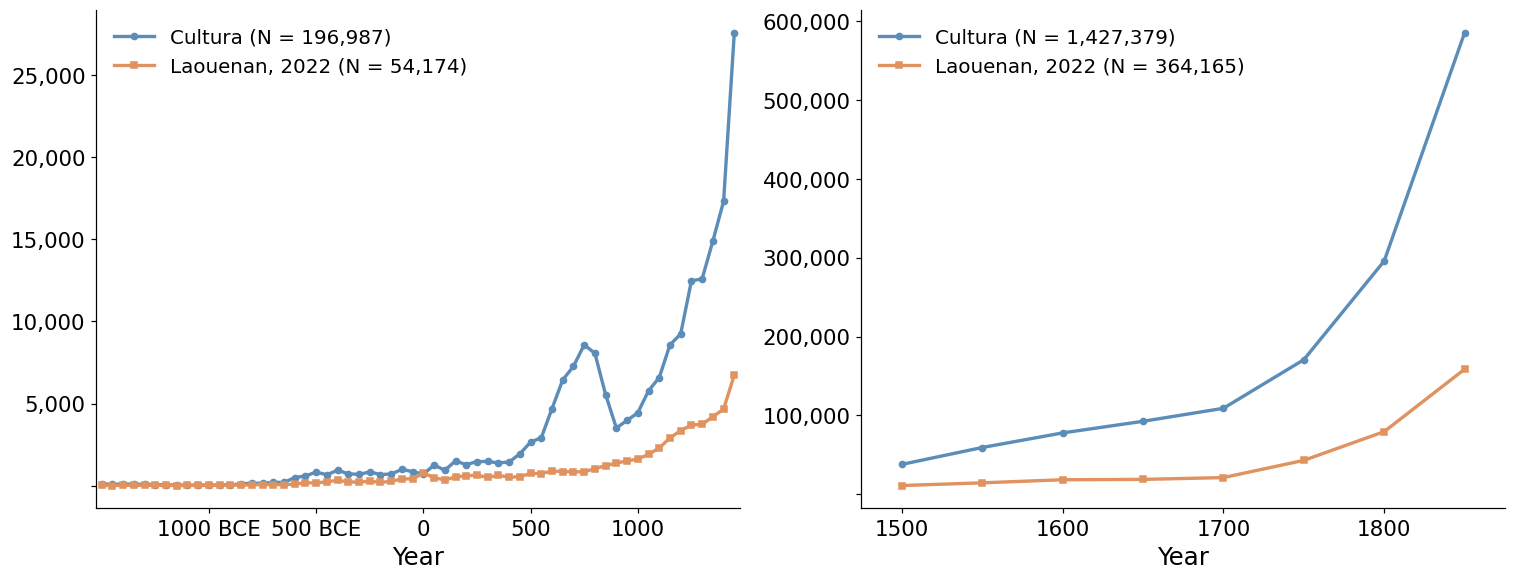

In [10]:
PRE_MODERN_BREAK = 1500
MODERN_END = 1900

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
masks = [bins_50y < PRE_MODERN_BREAK, (bins_50y >= PRE_MODERN_BREAK) & (bins_50y < MODERN_END)]
tick_sets = [np.arange(-1000, PRE_MODERN_BREAK, 500), np.arange(PRE_MODERN_BREAK, MODERN_END, 100)]
xlims = [(BIN_MIN - 25, PRE_MODERN_BREAK - 25), (PRE_MODERN_BREAK - 25, MODERN_END - 25)]

for ax, mask, ticks, xlim in zip(axes, masks, tick_sets, xlims):
    ax.plot(bins_50y[mask], cultura_per_bin[mask], color=COLORS['cultura'], lw=2.2, marker='o', ms=4,
            label=f'Cultura (N = {int(cultura_per_bin[mask].sum()):,})')
    ax.plot(bins_50y[mask], cross_verified_per_bin[mask], color=COLORS['cross_verified'], lw=2.2, marker='s', ms=4,
            label=f'Laouenan, 2022 (N = {int(cross_verified_per_bin[mask].sum()):,})')
    ax.set_xlim(*xlim)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in ticks])
    ax.yaxis.set_major_formatter(thousands)
    ax.set_xlabel('Year')
    ax.legend(loc='upper left')

fig.tight_layout()
plt.show()

### Fig 2 — Cultura vs Cross-Verified per 50-year bin by continent (log scale)

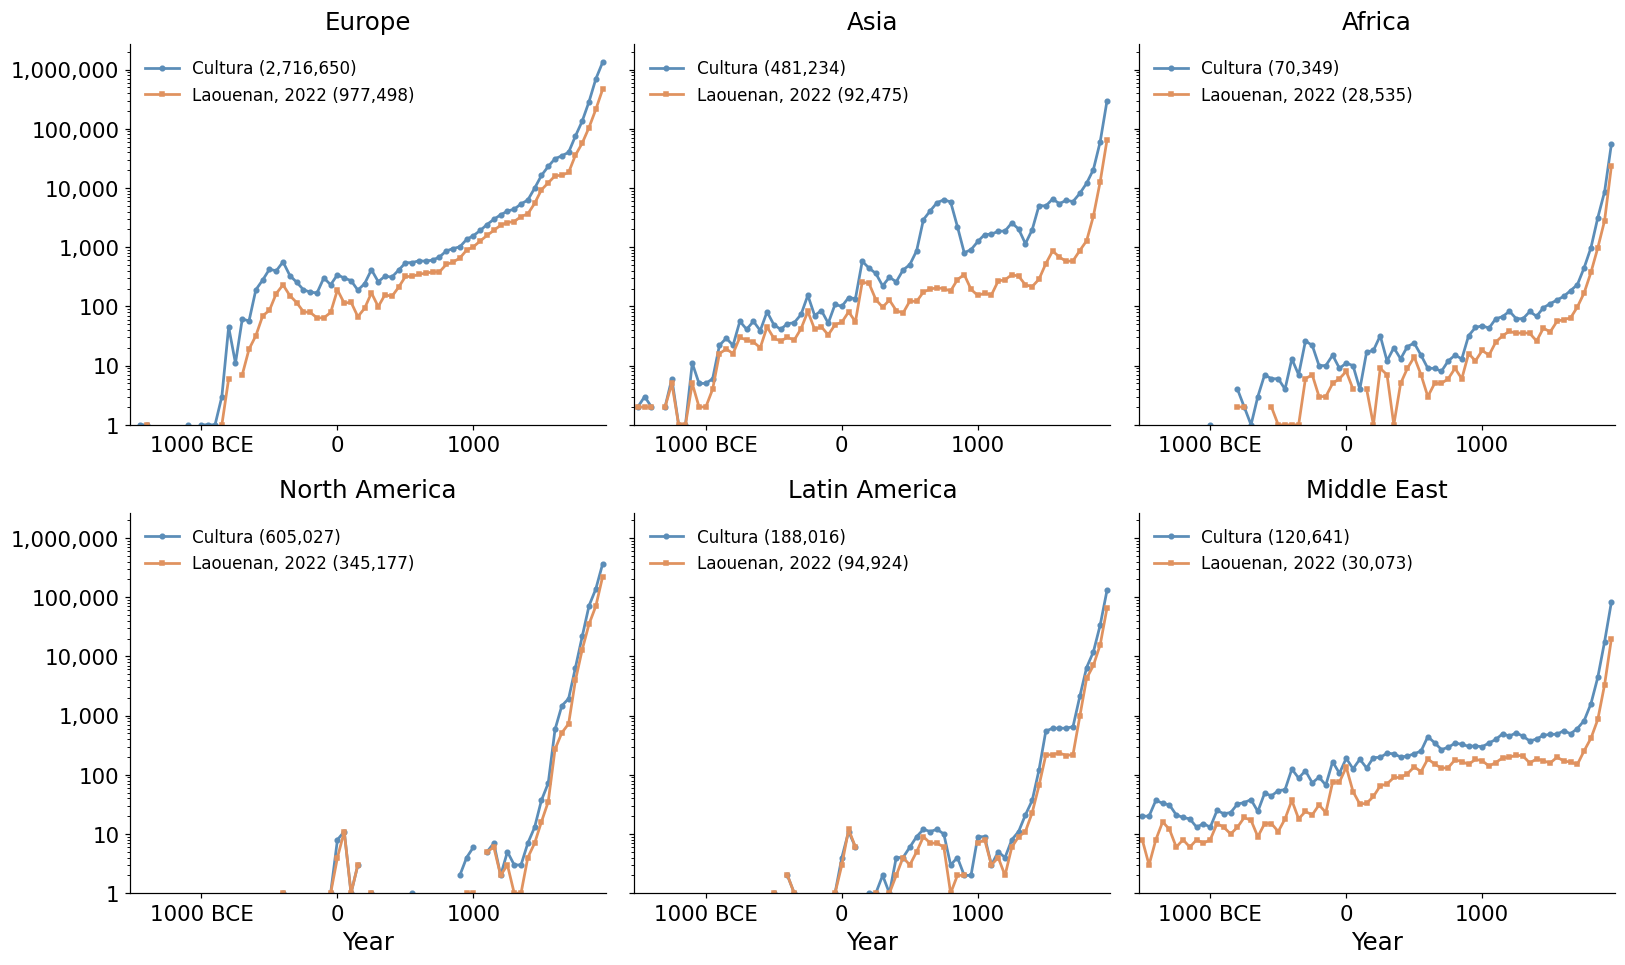

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
y_top = max(max(s['cultura'].max(), s['cross_verified'].max()) for s in continent_series.values()) * 2
ticks = np.arange(-1000, BIN_MAX_START + 1, 1000)

for ax, continent in zip(axes.flat, CONTINENTS):
    s = continent_series[continent]
    ax.plot(bins_50y, np.where(s['cultura'] > 0, s['cultura'], np.nan), color=COLORS['cultura'],
            lw=1.8, marker='o', ms=3, label=f"Cultura ({int(s['cultura'].sum()):,})")
    ax.plot(bins_50y, np.where(s['cross_verified'] > 0, s['cross_verified'], np.nan), color=COLORS['cross_verified'],
            lw=1.8, marker='s', ms=3, label=f"Laouenan, 2022 ({int(s['cross_verified'].sum()):,})")
    ax.set_yscale('log')
    ax.set_ylim(1, y_top)
    ax.set_xlim(BIN_MIN - 25, BIN_MAX_START + 25)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in ticks])
    ax.yaxis.set_major_formatter(thousands)
    ax.set_title(continent, fontsize=16, color='black', pad=10)
    ax.legend(loc='upper left', fontsize=11)

for ax in axes[-1, :]:
    ax.set_xlabel('Year')
fig.tight_layout()
plt.show()

### Fig 3 — Linear scale up to 1500 CE for Europe, Asia and the Middle East

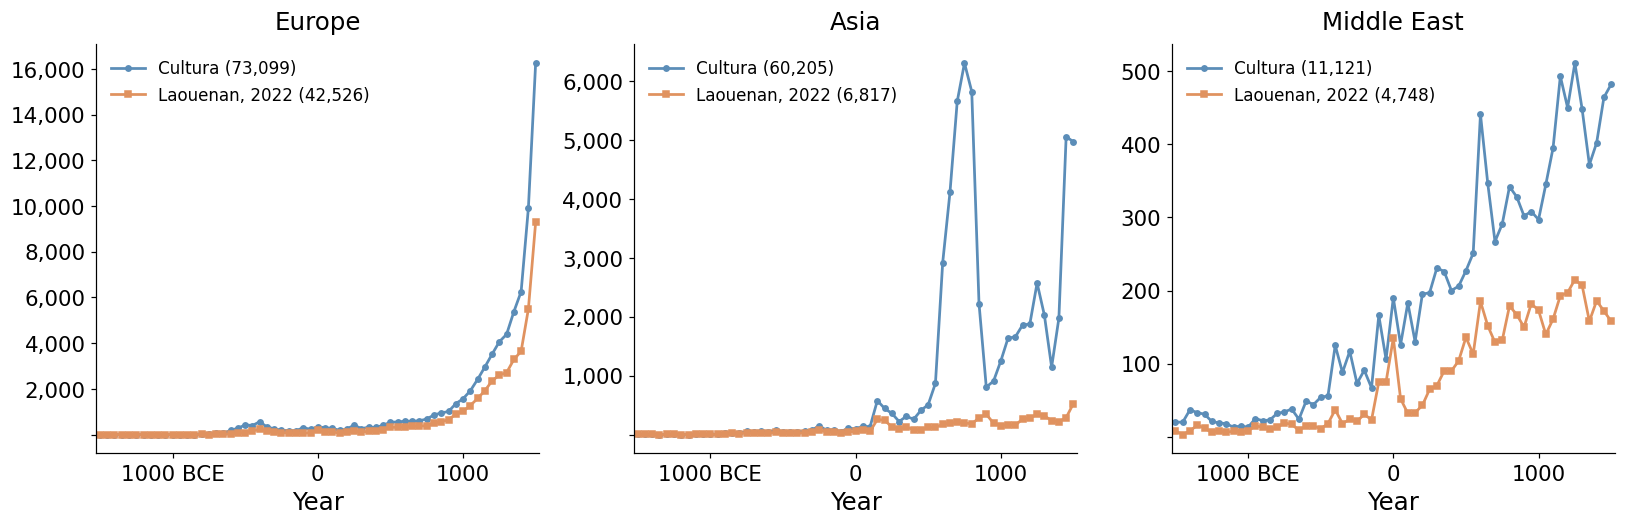

In [12]:
X_AXIS_END = 1500
FOCUS_CONTINENTS = ['Europe', 'Asia', 'Middle East']
keep = bins_50y <= X_AXIS_END
panel_ticks = np.arange(-1000, X_AXIS_END + 1, 1000)

fig, axes = plt.subplots(1, len(FOCUS_CONTINENTS), figsize=(15, 5))
for ax, continent in zip(axes, FOCUS_CONTINENTS):
    s = continent_series[continent]
    ax.plot(bins_50y[keep], s['cultura'][keep], color=COLORS['cultura'], lw=1.8, marker='o', ms=3.5,
            label=f"Cultura ({int(s['cultura'][keep].sum()):,})")
    ax.plot(bins_50y[keep], s['cross_verified'][keep], color=COLORS['cross_verified'], lw=1.8, marker='s', ms=3.5,
            label=f"Laouenan, 2022 ({int(s['cross_verified'][keep].sum()):,})")
    ax.set_xlim(BIN_MIN - 25, X_AXIS_END + 25)
    ax.set_xticks(panel_ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in panel_ticks])
    ax.yaxis.set_major_formatter(thousands)
    ax.set_title(continent, fontsize=16, color='black', pad=10)
    ax.set_xlabel('Year')
    ax.legend(loc='upper left', fontsize=11)

fig.tight_layout()
plt.show()

In [13]:
con.close()